# Annotation
Main driver of this analysis is simple curiosity. We asked ourselves: "what if we could analyse lyrics of one of the most influential artist of our generation?". This is how we decided to take as a project dataset of all lyrics of Kanye West's studio-recorded albums.

# Dataset creation
The dataset is generated using all Kanye West studio-recorded albums lyrics from https://www.kaggle.com/datasets/convolutionalnn/kanye-west-lyrics-dataset. Moreover, due to absence of the last 5 albums in the file, we had to copypaste their lyrics from https://genius.com. This data is located in data/raws. After parsing, it was  processed using Claude Cowork and resulted as data/jsons. Each file has has recordings about songs in the format "id, album, year, track, bonus, title, lyrics".

Extending topic of Claude cowork: to compile raw data we have prompted Claude to find titles of all songs in files and write them in the right format. Each file was then carefully checked and approved by ourselves.


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from collections import Counter
import seaborn as sns
import torch

raw = pd.read_json("data/jsons/raw_full.json").sort_values(["year", "track"])
raw


/Users/working_account/PycharmProjects/KanyeWestLyricsAnalysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,album,year,track,bonus,title,lyrics
0,The College Dropout,2004,1,False,Intro,"[Intro: DeRay Davis]\nKanye, can I talk to you..."
1,The College Dropout,2004,2,False,We Don't Care,[Intro]\nOh yeah...\nI got the perfect song fo...
2,The College Dropout,2004,3,False,Graduation Day,"[Spoken: DeRay]\nWhat in the fuck was that, Ka..."
3,The College Dropout,2004,4,False,All Falls Down,"[Chorus: Syleena Johnson & Kanye West]\nOh, wh..."
4,The College Dropout,2004,5,False,I'll Fly Away,One glad morning\nWhen this life is over\nI'll...
...,...,...,...,...,...,...
235,BULLY,2026,14,False,PREACHER MAN,"[Intro]\nAnd I\nRing that I hold, I—\nThis rin..."
236,BULLY,2026,15,False,BEAUTY AND THE BEAST,[Pre-Chorus]\nIt's been a long time coming\nFr...
237,BULLY,2026,16,False,DAMN,"[Chorus]\nDamn, damn, damn\nDid I ruin your pl..."
238,BULLY,2026,17,False,LAST BREATH,"[Chorus: Peso Pluma]\nBésame, mamá (Bésame), c..."


At this moment we have raw basic dataset that is ready to be cleaned up, explored, transformed and analysed.

# Cleaning
Let's check data for validity

In [3]:
report = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "non_null": raw.notna().sum().values,
    "null_pct": (raw.isna().mean() * 100).round(1).values,
    "nunique": raw.nunique(dropna=True).values,
})
print(report)

   column  dtype  non_null  null_pct  nunique
0   album    str       240       0.0       14
1    year  int64       240       0.0       13
2   track  int64       240       0.0       32
3   bonus   bool       240       0.0        2
4   title    str       240       0.0      239
5  lyrics    str       240       0.0      240


Superficial report shows that all datatypes are right, there is no Nan values. Moreover, all unique values are in the proper ranges, except, maybe title. Let's explore each column

In [4]:
# year
print(f"Year ranges from {raw["year"].min()} to {raw["year"].max()}")

Year ranges from 2004 to 2026


That coincides with official data

In [5]:
# title
duplicate_mask = raw["title"].duplicated(keep=False)
print(raw.loc[duplicate_mask].sort_values("title"))

          album  year  track  bonus title  \
175     Donda 2  2022     12  False   530   
212  VULTURES 2  2024     12  False   530   

                                                lyrics  
175  [Intro: Swsh]\nBaby, yeah\nWoah, baby\nWho pic...  
212  [Intro: Swsh]\nBaby, yeah\nWoah, baby, who pic...  


There is only one duplicated title in the list of songs and the song "530" with this title really does exist in both albums: Donda 2 and Vultures 2.

Now we want to explore the "lyrics" column and clean it up from all non-lyric symbols

In [6]:
lyrics = raw["lyrics"]
# print(lyrics[23])
# print(lyrics[46])
print(lyrics[57])
# print(lyrics[108])
# it seems like the only thing to remove is names of parts in brackets. for example:
# [Chorus]
# [Spoken Word: Max B & French Montana]
# [Intro: Mos Def]

[Intro: Mos Def]
I'm not sure anymore, more
Who is knocking at my door, door
All the faces that I know
Ja make them so sunny and true

[Chorus: Mos Def]
I don't wanna say goodbye, to you
So I'll just say good night, to you
My people, no goodbyes to you
I'm just gon' say good night

[Verse 1: Kanye West]
Uh
Good night
Right now I can see it so vivid
Like it was just yesterday, like I could relive it
Me and my grandparents on a field trip
And I'm the little kid tryna touch the exhibits
But it'll fade before I get to get a hold of that
Man, I wish I could stop time like a photograph
Every joke that they told I'd know to laugh
Man (man), I wouldn't let a moment pass
What do it mean when you dream that you fallin'?
What do it mean when you dream that you ballin'?
What do it mean when you never dream at all then
And you don't really know 'cause you can't recall them?
It's sorta fly you get a chance to say hi to
People you never got a chance to say bye to
Maybe you could pull em up outta your

In [7]:

rep = r"\[([^\]]*)\]"
rep1 =r"[()]"

we manually looked through the lyrics and all songs (except the "Last Call") has the same structure: set of songs parts of the form:
`"[{name of part}] {lyrics of part}"`

For example:
```
[Chorus: Mos Def]
I don't wanna say goodbye, to you
So I'll just say good night, to you
My people, no goodbyes to you
I'm just gon' say good night
```

But there wasone song -- "Last Call", where some lyrics were in square brackets. We've manually removed the brackets where it was necessary.

Now we can clean the data from square brackets and compare results

In [47]:
clean = raw.copy()
clean["lyrics"] = clean["lyrics"].apply(lambda lyr: re.sub(rep, "", lyr).strip())
clean["lyrics"] = clean["lyrics"].apply(lambda lyr: re.sub(rep1, "", lyr).strip())
n = 50
print("="*n, "RAW", "="*n)
print(*raw.query("index == 13")["lyrics"].values)
print()
print()
print("="*n, "CLEAN", "="*n)
print(*clean.query("index == 13")["lyrics"].values)

================================================== RAW ==================================================
[Skit 1: DeRay Davis]
Now beat that!
And your mother's saying "Go to college"
So you finish college and it's wonderful
You feel so good
And after all the partying and craziness
And don't forget about that drug habit you picked up at school being around your peers
Hey!
Now you'll get that 25-thousand dollar job a year
And you'll spend all your money on crack cocaine
But, it'll be YOUR money
No more borrowing from mom for my high!
So now you get your degree tattooed on your back
Cause you're so excited about it
If you continue to work at the Gap, after several interviews, oh my God
You'll come in at a entry-level position
And when you do that
If you kiss enough ass
You'll move up to the next level
Which is being the secretary's secretary
And boy is that great
You get to take messages for the secretary
Who NEVER went to college
She's actually the boss's niece!
So now you're part of th

Now the dataset is clean. Before describing it we are left with some preparation work to do.
Firstly, we want to mark the songs that are too short, as too short songs may break the analysis.

                     title  n_words
20               Last Call     2839
151        Jesus Lord Pt 2     1971
159             Jesus Lord     1456
136           Off the Grid     1349
110  No More Parties in LA     1170


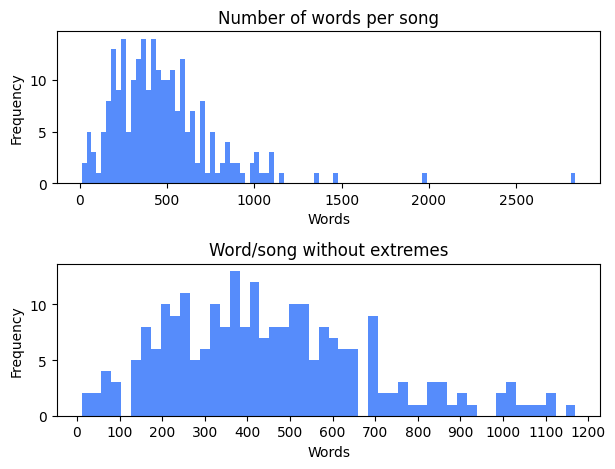

In [9]:


clean["n_words"] = clean["lyrics"].apply(lambda x: len(x.split()))
print(clean.sort_values(["n_words"], ascending=False)[["title", "n_words"]].head(5))
#here we checked if all anomalies are really the valid songs with valid number of words.
# in fact, these are truly one of the longest Kanye's songs
fig, ax = plt.subplots(2)
# fig.set_figwidth(1000)
# fig.set_figheight(500)
ax[0].hist(clean["n_words"], bins=100, rwidth=1)
ax[0].set_xlabel("Words")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Number of words per song")

ax[1].hist(clean.query("n_words < 1300")["n_words"], bins=50, rwidth=1)
ax[1].set_xlabel("Words")
ax[1].set_ylabel("Frequency")
ax[1].set_xticks(range(0, 1300, 100))
ax[1].set_title("Word/song without extremes")
plt.tight_layout()
plt.show()

so we have about 100 words as the limit for the short words. Let's show this in the dataset

In [10]:
clean["short"] = clean["n_words"].apply(lambda x: x <=100)
clean = clean.reset_index(drop=True)

# Lexical analysis (Simeon)

In [11]:
lex = clean.copy()

# Semantic analysis (Dmtirii)
In this part we will analyse lyrics from the perspective of semantics. It will be splitted into two blocks, but before that we need to prepare basics. 
## Preparation
As we have to analyse the semantics of each track, we'll be using embedding model, which transfers a block of text (i.e. chorus, track or line) into the vector of 768 dimensions, which represents it's position in the semantic space. 

In [12]:
sem = clean.copy()

We are using the [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) model, as it has 512 tokens of context and decent benchmarks.

In [13]:
# tok = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

tokenizer = model.tokenizer
model.max_seq_length = 512
print(model.similarity_fn_name)
print(model.max_seq_length)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8064.49it/s]


cosine
512


## Block 1: topic analysis.
In this block we have chosen several topics that are the most relevant to the Kanye's artwork and created the list of words-anchors for each topic. 

The idea is to calculate the relevance of each track to a specific topic, using cosine-similarity, which shows directional semantic similarity of track and anchor ignoring magnitude. this means, we measure, how similar are topics of track and anchor without taking into account the length of both. 

As we use the model, where 512 tokens per query is the architectural ceiling, we will split each song into chunks, and then take mean between the chunks. This draws a problem: the more average the result, the less precise it becomes.
Let's see, how much chunks we will need for the songs.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (869 > 512). Running this sequence through the model will result in indexing errors


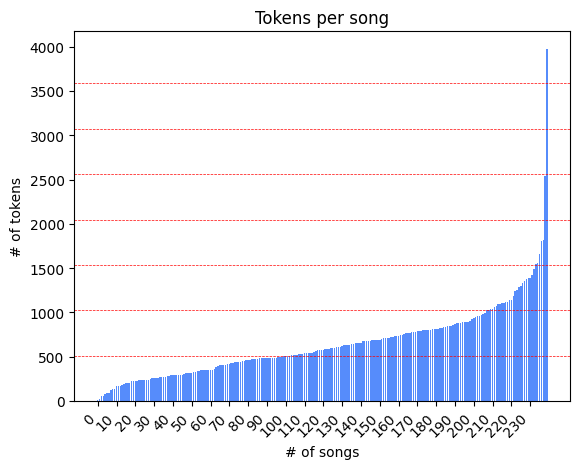

In [14]:
def n_tokens(text):
    return len(model.tokenizer.encode(text, add_special_tokens=True))

sem["n_tokens"] = sem["lyrics"].apply(n_tokens)

plt.bar(np.arange(sem.shape[0]), sem.sort_values("n_tokens")["n_tokens"])
max_tokens = model.get_max_seq_length()
for x in range(sem["n_tokens"].max()//max_tokens):
    plt.axhline(max_tokens * (x+1), color="red", linestyle="--", lw=0.5)
plt.xticks(np.arange(0, sem.shape[0], 10), rotation=45, ha="right")
plt.xlabel("# of songs")
plt.ylabel("# of tokens")
plt.title("Tokens per song")
plt.show()

We see, that about 110 songs fit into 512 limit. next 105 songs need to be splitted into two chunks and about 25 songs will require 3 chunks. other songs will be splitted into more parts.
This is acceptable, as averaging 2-3 chunks will not disturb embeddings.

The procces of chunking is the following: 
1. Split each song on chunks
2. encode each chunk
3. Find the average of chunks for each track

In [15]:
flatten_chunks = []
owners = []
        
for i, row in sem.iterrows():
    lyrics = row["lyrics"].split("\n")
    curr = ""
    for l in lyrics:
        if curr != "":
            candidate = curr + '\n'+ l
        else:
            candidate = l 
        if len(tokenizer.encode(candidate)) > max_tokens:
            if curr != "":
                flatten_chunks.append(curr)
                owners.append(i)
            curr = l
        else:
            curr = candidate
    if curr != "":
        flatten_chunks.append(curr)
        owners.append(i)
print(*list(zip( owners, flatten_chunks))[:4], sep="\n\n")

(0, "Kanye, can I talk to you for a minute?\nMe and the other faculty members was wonderin'\nCould you do a lil' som...\nSomethin' beautiful, somethin' that the kids are gon' love when they hear it\nThat's gon' make them start jumpin' up and down, and sharin' candy and stuff\nThink you could probably do somethin', for the kids, for graduation to sing?")

(1, 'Oh yeah...\nI got the perfect song for the kids to sing...\nAnd all my people that\'s—\n\n\nDrug dealin\' just to get by\nStack your money \'til it get sky high\nWe wasn\'t supposed to make it past 25\nJoke\'s on you, we still alive\nThrow your hands up in the sky and say\n"We don\'t care what people say"\n\n\nIf this is your first time hearin\' this\nYou are about to experience somethin\' so cold, man\nWe never had nothin\' handed, took nothin\' for granted\nTook nothin\' from no man, man, I\'m my own man\nBut as a shorty, I looked up to the dope man\nOnly adult man I knew that wasn\'t broke, man\nFlickin\' Starter coats, man, ma

Let's check how we splitted songs.

In [16]:


assert len(flatten_chunks) == len(owners), \
    f"length mismatch: {len(flatten_chunks)} chunks vs {len(owners)} owners"
print("total chunks:", len(flatten_chunks))
print("owner tracks:", len(set(owners)))

empties = [k for k, c in enumerate(flatten_chunks) if not c or c.strip() == ""]
print("empty chunks:", len(empties))
assert not empties, f"empty chunks at positions {empties[:10]}"

lens = [len(tokenizer.encode(c)) for c in flatten_chunks]
over = [(k, L) for k, (c, L) in enumerate(zip(flatten_chunks, lens)) if L > max_tokens]
print("chunks over limit:", len(over))
if over:
    print("  examples (pos, length):", over[:5])
print("chunk lengths — max:", max(lens), "| median:", int(np.median(lens)))

per_track = Counter(owners)
counts = np.array(list(per_track.values()))
print("chunks per track — min:", counts.min(),
      "| max:", counts.max(), "| mean:", round(counts.mean(), 2))

has_text = set(sem.index[sem["lyrics"].notna() & (sem["lyrics"].str.strip() != "")])
lost = has_text - set(owners)
print("tracks with text but no chunk:", len(lost))
if lost:
    print("  lost positions:", list(lost)[:10])

longest_pos = sem["n_tokens"].idxmax()
own_chunks = [flatten_chunks[k] for k in range(len(owners)) if owners[k] == longest_pos]
sum_chunks = sum(len(tokenizer.encode(c)) for c in own_chunks)
track_len = len(tokenizer.encode(sem.loc[longest_pos, "lyrics"]))
print(f"\nlongest track (pos {longest_pos}): {len(own_chunks)} chunks")
print(f"  sum of chunk tokens: {sum_chunks} | track length: {track_len}")
print(f"  diff: {sum_chunks - track_len}")

total chunks: 425
owner tracks: 240
empty chunks: 0
chunks over limit: 0
chunk lengths — max: 512 | median: 448
chunks per track — min: 1 | max: 9 | mean: 1.77
tracks with text but no chunk: 0

longest track (pos 20): 9 chunks
  sum of chunk tokens: 3988 | track length: 3972
  diff: 16


As we see, everything is clear, we can continue on encoding

In [17]:
encoded = model.encode(flatten_chunks, batch_size=32, show_progress_bar=True)

Batches: 100%|██████████| 14/14 [00:27<00:00,  1.98s/it]


And the final step is to find the average for each track and save the results

In [18]:
owners = np.array(owners)
track_vectors = np.zeros((len(sem), encoded.shape[1]), dtype=np.float32)

for t in range(len(sem)):
    mask = owners == t
    if mask.any():
        track_vectors[t] = encoded[mask].mean(axis=0)
        
track_vectors = track_vectors / np.linalg.norm(track_vectors, axis=1, keepdims=True)
np.save("track_vectors.npy", track_vectors)

In [19]:
track_vectors = np.vstack(np.load("track_vectors.npy"))

Then we have determined 9 main topics in Kanye's career and created two anchors for each topic based on the popular key-words. The themes are:
religion, wealth, fame, ego, love, mental, race, family, sex.

In [20]:
THEME_ANCHORS = {
    "religion": "Faith in God and Jesus, prayer, worship, gospel and church, salvation from sin, fighting the devil and demons, repentance, blessings, and seeking divine grace.",
    "wealth": "Money, cash, wealth, luxury goods, designer clothes, jewelry, diamonds, cars, mansions, expensive purchases, brands, spending, financial success, and material possessions.",
    "fame": "Public attention, celebrity visibility, media scrutiny, tabloids, paparazzi, cameras, interviews, fans, headlines, reputation, loss of privacy, and the pressure of being watched.",
    "ego": "Extreme self-confidence, pride, genius, greatness, superiority, ambition, bragging, self-importance, being the best, personal power, and belief in one's own exceptional talent.",
    "love": "Romantic relationships between partners, dating, commitment, affection, trust, jealousy, breaking up, getting back together, missing an ex-lover, and emotional conflict within a couple.",
    "mental": "Mental illness and psychological distress, bipolar disorder, mania, depression, anxiety, paranoia, intrusive thoughts, medication, therapy, instability, and struggling with one's mind.",
    "race": "Being Black in America, racism and discrimination, slavery and its legacy, systemic oppression and white supremacy, mass incarceration, civil rights, and the struggle for Black liberation.",
    "family": "Mother, father, parents, children, daughter, son, home, kinship, family bonds, upbringing, ancestry, generations, parenthood, and responsibility to one's relatives.",
    "sex": "Sexual desire, lust, bodies, physical intimacy, erotic attraction, seduction, sexual acts, carnal pleasure, flesh, hookups, and bodily passion without romantic commitment.",
}

THEME_ANCHORS_ALT = {
    "religion": "Calling on the Lord and the Almighty, spiritual devotion and belief, scripture and the Bible, redemption and being saved, resisting Satan and temptation, asking heaven for mercy and protection.",
    "wealth": "Riches, dollars, gold chains, watches, high-end fashion labels, luxury cars, houses, shopping, expensive taste, possessions, and the material lifestyle of having money.",
    "fame": "Living under public observation, being followed by photographers, appearing in the press, gossip coverage, audience judgment, fame pressure, public image, and life without privacy.",
    "ego": "A larger-than-life self-image, claiming greatness, feeling unmatched, self-praise, confidence, arrogance, visionary ambition, dominance, and belief in personal excellence.",
    "love": "A boyfriend or girlfriend relationship, romance between lovers, couple problems, loyalty and betrayal, arguments, separation, reconciliation, longing for a romantic partner, and the ups and downs of dating.",
    "mental": "A troubled mind, manic episodes, depressive lows, panic, paranoia, psychiatric treatment, prescriptions, emotional dysregulation, inner chaos, and mental health crisis.",
    "race": "Black identity and the African American experience, racial injustice and prejudice, the chains of bondage and the cotton fields, institutional inequality and corporate exploitation, the prison system, fighting for freedom and equality.",
    "family": "Mom, dad, kids, raising children, being a parent, family home, relatives, childhood, generational ties, family duty, and the people who raised you.",
    "sex": "Erotic craving, physical pleasure, sexual encounters, touching bodies, lustful attraction, sensual temptation, hookups, and carnal desire.",
}

In [21]:
# Now we will encode each topic
enc_themes = dict()
enc_themes_alt = dict()
for k, v in THEME_ANCHORS.items():
    enc_themes[k] = model.encode(v, normalize_embeddings=True)
    enc_themes_alt[k] = model.encode(THEME_ANCHORS_ALT[k], normalize_embeddings=True)
names = list(enc_themes.keys())
topic_vectors = np.vstack([enc_themes[k] for k in names])
topic_vectors_alt = np.vstack([enc_themes_alt[k] for k in names])

before scoring tracks we want to check whether topics are independent enough. to do that, we use cosine similarity between topic to measure, how close some of them to other.
## Correlational validation

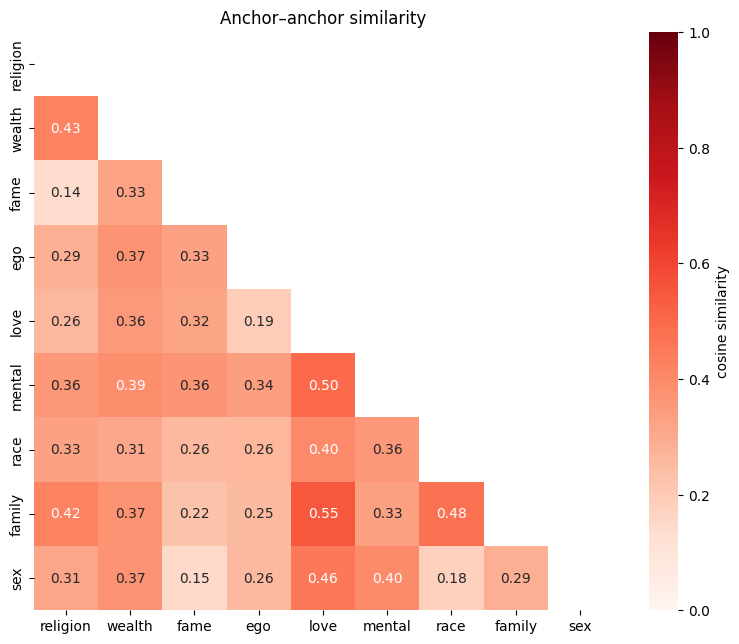

In [22]:
collision = model.similarity(np.vstack(topic_vectors), np.vstack(topic_vectors))
mat  = collision.numpy()
mask = np.triu(np.ones_like(mat, dtype=bool))   # прячем диагональ + верхний треугольник

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    mat, mask=mask, annot=True, fmt=".2f",
    xticklabels=names, yticklabels=names,
    cmap="Reds", vmin=0, vmax=1, square=True,
    cbar_kws={"label": "cosine similarity"}, ax=ax,
)
ax.set_title("Anchor–anchor similarity")
plt.tight_layout()
plt.show()

We see, that there are no major correlations between topics, so we can skip merging them.

As we have got embedings for each topic, we can evaluate, how close each track to a specific topic, using cosine similarity. Result for a topic {name} will be in the columns close_to_{name} and close_to_{name}_ALT.

In [23]:

scores = model.similarity(torch.tensor(track_vectors), torch.tensor(topic_vectors))
scores_alt = model.similarity(torch.tensor(track_vectors), torch.tensor(topic_vectors_alt))
print(scores.shape)
for i, topic in enumerate(names):
    sem[f"close_to_{topic}"] = scores[:, i].cpu().numpy()
    sem[f"close_to_{topic}_ALT"] = scores_alt[:, i].cpu().numpy()


torch.Size([240, 9])


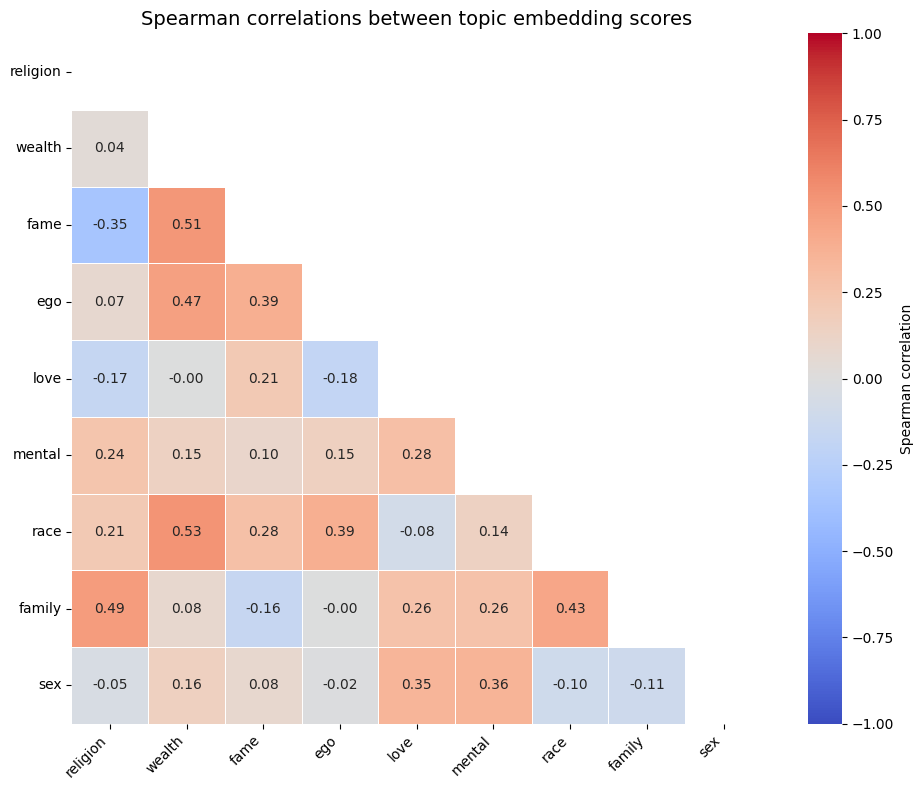

In [24]:
from scipy.stats import rankdata

cols = [f"close_to_{t}" for t in names]          # поправь, если имена колонок другие
S = sem[cols].rename(columns=lambda c: c.replace("close_to_", ""))

corr = S.corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,          # показываем числа внутри клеток
    fmt=".2f",           # округление до 2 знаков
    cmap="coolwarm",     # синий = отрицательная, красный = положительная
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title("Spearman correlations between topic embedding scores", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Now we have to check each topic for stability. In order to do that, we will evaluate Spearman's correlation between main and alternative formulations of each topic.

In [25]:
# Stability between anchors of topic
from scipy.stats import spearmanr
stability = {}
stability_clean = {}
for topic in names:
    r, _ = spearmanr(sem[f"close_to_{topic}"], sem[f"close_to_{topic}_ALT"])
    r1, _ = spearmanr(sem[~sem.short][f"close_to_{topic}"], sem[~sem.short][f"close_to_{topic}_ALT"])
    stability[topic] = round(r, 3)
    stability_clean[topic] = round(r1, 3)
stability = pd.Series(stability).T.sort_values()
stability_clean = pd.Series(stability_clean).T.sort_values()
print(stability)
print()
print(stability_clean)

ego         0.841
love        0.900
race        0.921
religion    0.923
family      0.924
fame        0.932
wealth      0.937
sex         0.938
mental      0.939
dtype: float64

ego         0.847
love        0.902
religion    0.920
race        0.928
fame        0.930
family      0.930
mental      0.936
sex         0.936
wealth      0.938
dtype: float64


IMPORTANT
hypothesis "short songs impact stability" didn't confirm.

In [26]:
# length-topic correlation
length_topic = {}
for topic in names:
    r, _ = spearmanr(sem[~sem.short][f"close_to_{topic}"], sem[~sem.short][f"n_words"])
    length_topic[topic] = round(r, 3)
length_topic = pd.Series(length_topic).sort_values(ascending=False)
length_topic

fame        0.308
race        0.295
wealth      0.261
ego         0.251
sex         0.074
mental      0.040
family     -0.082
religion   -0.098
love       -0.113
dtype: float64

In [27]:
k = 10
top_overlap = {}
for topic in names:
    top_main = set(sem[~sem.short].nlargest(k, f"close_to_{topic}")["title"])
    print(f"{topic}: {top_main}")
    print()
    top_alt = set(sem[~sem.short].nlargest(k, f"close_to_{topic}_ALT")["title"])
    top_overlap[topic] = round(len(top_main&top_alt)/k, 3)
top_overlap = pd.Series(top_overlap)    
top_overlap

religion: {'Use This Gospel', 'Every Hour', 'BELIEVER', 'Water', 'God Is', 'Never Abandon Your Family', 'Up from the Ashes', 'Selah', 'PUNCH DRUNK', 'MY SOUL'}

wealth: {'Real Friends', 'The Glory', 'Eazy', 'Diamonds from Sierra Leone (Remix)', 'So Appalled', 'New Slaves', 'Selfish', "Can't Tell Me Nothing", 'Facts (Charlie Heat Version)', 'Skit #1'}

fame: {'Real Friends', 'King', 'No More Parties in LA', 'Say You Will', 'Bad News', 'Burn', 'Pinocchio Story', 'Diamonds from Sierra Leone (Remix)', 'Praise God', 'Last Call'}

ego: {'Amazing', 'Champion', 'The Glory', 'Good Morning', "MAMA'S FAVORITE", 'Donda', 'So Appalled', 'Facts (Charlie Heat Version)', 'School Spirit Skit 2', 'Last Call'}

love: {'HUSBAND', 'HIGHS AND LOWS', 'We Can Make It Better', 'Coldest Winter', '530', "Wouldn't Leave", 'Blood on the Leaves', 'Believe What I Say', 'Love Lockdown'}

mental: {'HIGHS AND LOWS', 'Jail', 'Hurricane', 'Say You Will', 'Yikes', 'Paranoid', 'CAN U BE', 'See You in My Nightmares', 'Power

religion    0.7
wealth      0.9
fame        0.6
ego         0.8
love        0.7
mental      0.7
race        0.7
family      0.7
sex         0.9
dtype: float64

## Block 2 -- intra-song coherence

In [50]:
# explore the form of lyrics. look at random lyrics
lyrics = sem[["title", "lyrics"]]
n = 113
print(lyrics["title"][n])
print(lyrics["lyrics"][n])

Saint Pablo
Yeah, 9:08 L.A. time
Back in the lab and shit


My wife said, "I can't say no to nobody"
And at this rate we gon' both die broke
Got friends that ask me for money knowin' I'm in debt
And like my wife said, I still didn't say no
People tryna say I'm goin' crazy on Twitter
My friends' best advice was to stay low
I guess it's hard to decipher all of the bills
Especially when you got family members on payroll
The media said it was outlandish spendin'
The media said he's way out of control
I just feel like I'm the only one not pretendin'
I'm not out of control, I'm just not in they control
I know I'm the most influential
That TIME cover was just confirmation
This generation's closest thing to Einstein
So don't worry about me, I'm fine
I can see a thousand years from now in real life
Skate on the paradigm and shift it when I feel like
Troll conventional thought, don't need to question
I know it's antiquated so sometimes I get aggressive
Thank God for Jay Electra, he down with the

In [58]:
def split_track(lyrics):
    chunks = []
    lyrics = lyrics.split("\n\n\n")
    for verse in lyrics:
        if len(tokenizer.encode(verse)) <= max_tokens:
            chunks.append(verse)
        else:
            curr = ""
            for s in verse.split("\n"):
                if curr != "":
                    candidate = curr + '\n'+ s
                else:
                    candidate = s
                if len(tokenizer.encode(candidate)) > max_tokens:
                    if curr != "":
                        chunks.append(curr)
                    curr = s
                else:
                    curr = candidate
            if curr != "":
                chunks.append(curr)
    return chunks
print(*split_track(lyrics["lyrics"][n]), sep="\n\n")

Yeah, 9:08 L.A. time
Back in the lab and shit

My wife said, "I can't say no to nobody"
And at this rate we gon' both die broke
Got friends that ask me for money knowin' I'm in debt
And like my wife said, I still didn't say no
People tryna say I'm goin' crazy on Twitter
My friends' best advice was to stay low
I guess it's hard to decipher all of the bills
Especially when you got family members on payroll
The media said it was outlandish spendin'
The media said he's way out of control
I just feel like I'm the only one not pretendin'
I'm not out of control, I'm just not in they control
I know I'm the most influential
That TIME cover was just confirmation
This generation's closest thing to Einstein
So don't worry about me, I'm fine
I can see a thousand years from now in real life
Skate on the paradigm and shift it when I feel like
Troll conventional thought, don't need to question
I know it's antiquated so sometimes I get aggressive
Thank God for Jay Electra, he down with the mission
Did 

For each track we need:
1. Get chunks
2. evalutate normalized embeddings for chunks.
3. if n_chunk == 1 put nan
4. find cossim for each pair of chunks using V @ V.T
5. average the upper triangle
6. put resulted value Into coherence

In [69]:
# evaluating intra-song coherence
def get_coherence(lyrics):
    chunks = split_track(lyrics)
    n_verses = len(chunks)
    if n_verses == 1:
        return (np.nan, 1)
    embds = model.encode(chunks, normalize_embeddings=True)
    S = embds @ embds.T
    upper_i = np.triu_indices(n_verses, k=1)
    return (S[upper_i].mean(), n_verses)

print(get_coherence(lyrics["lyrics"][n]))


(np.float32(0.38888097), 8)


In [70]:
sem[["coherence", "n_verses"]] = sem["lyrics"].apply(lambda x: get_coherence(x)).apply(pd.Series)

In [77]:
sem.head(10)

,album,year,track,bonus,title,lyrics,n_words,short,n_tokens,close_to_religion,...,close_to_mental,close_to_mental_ALT,close_to_race,close_to_race_ALT,close_to_family,close_to_family_ALT,close_to_sex,close_to_sex_ALT,coherence,n_verses
0,The College Dropout,2004,1,False,Intro,"Kanye, can I talk to you for a minute?\nMe and...",63,True,92,0.066461,...,0.055163,0.039834,0.171684,0.193157,0.103324,0.156705,-0.020140,0.003812,NaN,1.0
1,The College Dropout,2004,2,False,We Don't Care,Oh yeah...\nI got the perfect song for the kid...,635,False,869,0.028284,...,0.107673,0.080969,0.148614,0.198824,0.096602,0.148480,0.032847,0.030041,0.578152,8.0
2,The College Dropout,2004,3,False,Graduation Day,"What in the fuck was that, Kanye?! I told you ...",203,False,299,0.011606,...,0.138746,0.141629,0.274674,0.299053,0.150046,0.162826,0.077590,0.045375,0.356977,2.0
3,The College Dropout,2004,4,False,All Falls Down,"Oh, when it all, it all falls down\nYeah, this...",726,False,1042,0.027573,...,0.137944,0.158494,0.201933,0.282749,0.129242,0.162954,0.050343,0.042005,0.516305,7.0
4,The College Dropout,2004,5,False,I'll Fly Away,One glad morning\nWhen this life is over\nI'll...,41,True,55,0.151275,...,0.065979,0.081515,0.048914,0.118003,0.079654,0.123858,0.036050,0.013353,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,BULLY,2026,14,False,PREACHER MAN,"And I\nRing that I hold, I—\nThis ring that I ...",403,False,518,0.169948,...,0.073203,0.054028,0.062847,0.163625,0.153494,0.142567,0.086950,0.070467,0.337826,7.0
236,BULLY,2026,15,False,BEAUTY AND THE BEAST,"It's been a long time coming\nFresh new tires,...",187,False,264,0.029215,...,0.097264,0.074863,0.082378,0.121266,0.073096,0.109764,0.051081,0.033223,0.421335,5.0
237,BULLY,2026,16,False,DAMN,"Damn, damn, damn\nDid I ruin your plans, plans...",213,False,275,0.133110,...,0.097251,0.096400,0.076963,0.129731,0.180910,0.216247,0.076331,0.065383,1.000000,3.0
238,BULLY,2026,17,False,LAST BREATH,"Bésame, mamá Bésame, como tú sabes\nDéjame, ma...",305,False,483,-0.021919,...,0.030333,0.043721,0.051050,0.087496,0.093767,0.107727,0.072511,0.085377,0.457141,9.0
